# CONFIGURANDO AMBIENTE

###libs


In [ ]:
pip install osmnx unidecode --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 10.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import geopandas as gpd
from io import BytesIO
import os
from urllib.request import urlopen, urlretrieve
from zipfile import ZipFile
from unidecode import unidecode
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from IPython.display import display
from google.colab import files  # ← para download no Colab

# FUNÇÕES

####setores censitarios

In [ ]:
def importar_setores_censitarios(sigla_uf):
    sigla_uf = sigla_uf.upper()
    url_base = 'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_de_setores_censitarios__divisoes_intramunicipais/censo_2022_preliminar/setores/gpkg/UF/'
    url_setores_censitarios = f'{url_base}{sigla_uf}/{sigla_uf}_Malha_Preliminar_2022.gpkg'
    nome_arquivo = f'{sigla_uf}_Malha_Preliminar_2022.gpkg'

    try:
        urlretrieve(url_setores_censitarios, nome_arquivo)
        setores = gpd.read_file(nome_arquivo)
        return setores
    except Exception as e:
        print(f"Erro ao importar os setores censitários: {e}")
        return None


#### obter uf

In [ ]:
def obter_codigo_uf(sigla_uf):
    codigos_ufs = {
        'AC': '12', 'AL': '27', 'AP': '16', 'AM': '13','BA': '29', 'CE': '23', 'DF': '53', 'ES': '32',
        'GO': '52', 'MA': '21', 'MT': '51', 'MS': '50', 'MG': '31', 'PA': '15', 'PB': '25', 'PR': '41',
        'PE': '26', 'PI': '22', 'RJ': '33', 'RN': '24','RS': '43', 'RO': '11', 'RR': '14', 'SC': '42',
        'SP': '35', 'SE': '28', 'TO': '17'
    }
    return codigos_ufs.get(sigla_uf.upper())

def obter_sigla_uf(codigo_uf):
    codigos_ufs = {
        '12': 'AC', '27': 'AL', '16': 'AP', '13': 'AM', '29': 'BA', '23': 'CE', '53': 'DF', '32': 'ES',
        '52': 'GO', '21': 'MA', '51': 'MT', '50': 'MS', '31': 'MG', '15': 'PA', '25': 'PB', '41': 'PR',
        '26': 'PE', '22': 'PI', '33': 'RJ', '24': 'RN', '43': 'RS', '11': 'RO', '14': 'RR', '42': 'SC',
        '35': 'SP', '28': 'SE', '17': 'TO'
    }
    return codigos_ufs.get(codigo_uf)

#### obter endereços

In [ ]:

def obter_endereços(sigla_uf):
    codigo_uf = obter_codigo_uf(sigla_uf)
    if not codigo_uf:
        print("Sigla da UF inválida ou não encontrada.")
        return None

    url_base = "https://ftp.ibge.gov.br/Cadastro_Nacional_de_Enderecos_para_Fins_Estatisticos/Censo_Demografico_2022/Coordenadas_enderecos/UF/"
    nome_arquivo_zip = f"{codigo_uf}_{sigla_uf.upper()}.zip"
    url_completa = f"{url_base}{nome_arquivo_zip}"

    try:
        with urlopen(url_completa) as zipresp:
            with ZipFile(BytesIO(zipresp.read())) as zfile:
                lista_arquivos = zfile.namelist()
                arquivo_csv = next((arq for arq in lista_arquivos if arq.endswith('.csv')), None)

                if arquivo_csv:
                    with zfile.open(arquivo_csv) as csvfile:
                        df = pd.read_csv(csvfile, sep =';')

        # Certifique-se de que os nomes das colunas correspondam exatamente ao que está no seu arquivo CSV
        if 'LATITUDE' in df.columns and 'LONGITUDE' in df.columns:
            gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['LONGITUDE'], df['LATITUDE']))
            gdf.crs = "EPSG:4674"
            return gdf
        else:
            print("Colunas de latitude/longitude não encontradas no DataFrame")
            return None
    except Exception as e:
        print(f"Erro ao processar o arquivo: {e}")
        return None

# Correção: 'AL' deve ser passado como uma string
enderecos = obter_endereços('al')


#### obter faces de logradouro

In [ ]:
def baixar_faces_logradouros_municipio(codigo_municipio, sigla_uf):
    sigla_uf_lower = sigla_uf.lower()
    sigla_uf_upper = sigla_uf.upper()
    codigo_municipio = str(codigo_municipio).zfill(7)  # Garante que o código do município tenha 7 dígitos

    # Montar a URL para download do arquivo ZIP
    url_base = 'https://geoftp.ibge.gov.br/recortes_para_fins_estatisticos/malha_de_setores_censitarios/censo_2010/base_de_faces_de_logradouros_versao_2021/'
    url_zip = f'{url_base}{sigla_uf_upper}/{sigla_uf_lower}_faces_de_logradouros_2021.zip'

    try:
        # Baixar o arquivo ZIP
        with urlopen(url_zip) as zipresp:
            with ZipFile(BytesIO(zipresp.read())) as zfile:
                # Extrair o conteúdo do ZIP para um diretório temporário
                temp_dir = 'temp_dir'
                zfile.extractall(temp_dir)
                # Procurar pelo arquivo .shp dentro do ZIP
                arquivo_shapefile = [arq for arq in os.listdir(temp_dir) if arq.endswith('.shp') and arq.startswith(codigo_municipio)][0]
                # Ler o shapefile
                shapefile_path = os.path.join(temp_dir, arquivo_shapefile)
                return gpd.read_file(shapefile_path)

    except Exception as e:
        print(f"Erro ao importar as faces de logradouros do município {codigo_municipio}: {e}")
        return None


#### Eixos de logradouro OSM

In [ ]:
import osmnx as ox
def baixar_eixos_osm(poligono_municipio, network_type='all'):
    """
    Baixa do OSM as "ways" com tag highway dentro de um polígono.

    Params:
    - poligono_municipio: shapely Polygon ou GeoDataFrame (unary_union é usado)
    - network_type: 'all', 'drive', 'walk', 'bike' etc.

    Returns:
    - GeoDataFrame com as arestas (eixos de logradouro) em EPSG:4674
    """
    # extrai shapely Polygon
    if hasattr(poligono_municipio, 'geometry'):
        poly = poligono_municipio.geometry.geometry.union_all()
    else:
        poly = poligono_municipio

    # configurações OSMnx
    ox.settings.use_cache = True
    ox.settings.log_console = False
    print("⏳ Baixando eixos de logradouro do OSM…")
    # baixa o grafo dentro do polígono
    G = ox.graph_from_polygon(poly, network_type=network_type, simplify=True)

    # converte só arestas
    gdf_edges = ox.graph_to_gdfs(G, nodes=False)
    # reprojeta para o CRS dos seus dados IBGE (EPSG:4674)
    gdf_edges = gdf_edges.to_crs('EPSG:4674')
    print(f"✅ {len(gdf_edges)} eixos OSM baixados e reprojetados.")

    return gdf_edges

#### Funções a contruir

#####Base cartográfica contínua

1.   lml_cidade_p
2.   lml_aglomerado_rural_p
3. fer_trecho_ferroviario_l
4. hid_massa_dagua_a
5. rod_trecho_rodoviario_l


#### dados municipio

In [ ]:


def dados_municipio(
    sigla_uf,
    codigo_municipio: str = None,
    nome_municipio: str = None,
    layers: list[int] = None
):
    """
    Baixa e processa várias camadas para um município e:
      1) Salva num GeoPackage
      2) Plota o mapa
      3) Dispara o download no Colab

    Parâmetros:
      sigla_uf: ex 'AL'
      codigo_municipio: string de 7 dígitos (inicia com código UF)
      nome_municipio: nome por extenso (sem acentos)
      layers: quais camadas incluir
        0=all, 1=Polígono,2=Setores,3=Endereços,4=Faces,5=Eixos
    """

    print("🔎 Iniciando dados_municipio()")
    # define seleção de camadas
    if layers is None or 0 in layers:
        selected = {1,2,3,4,5}
    else:
        selected = set(layers)
    print(f"👉 Camadas selecionadas: {sorted(selected)}")

    # 1) Resolver UF / município
    if codigo_municipio:
        codigo_uf = str(codigo_municipio)[:2]
        sigla_uf = obter_sigla_uf(codigo_uf)
    else:
        sigla_uf = sigla_uf.upper()
        nome_municipio = unidecode(nome_municipio).upper()
    print(f"✔️ UF = {sigla_uf}; município = {nome_municipio or codigo_municipio}")

    # 2) Setores censitários (sempre necessário)
    print("⏳ Importando setores censitários…")
    setores = importar_setores_censitarios(sigla_uf)
    if setores is None:
        raise RuntimeError("Erro ao importar setores censitários")
    if codigo_municipio:
        setores_mun = setores[ setores['CD_MUN'].str.startswith(codigo_municipio) ]
    else:
        setores_mun = setores[
            setores['NM_MUN'].apply(lambda x: unidecode(x).upper()) == nome_municipio
        ]
    if setores_mun.empty:
        raise RuntimeError("Nenhum setor encontrado para esse município")
    print(f"✅ {len(setores_mun)} setores encontrados")

    # polígono municipal (sempre necessário)
    poligono = setores_mun.geometry.union_all()
    gdf_polig = gpd.GeoDataFrame( geometry=[poligono], crs="EPSG:4674" )

    # 3) Endereços IBGE (só se 3)
    if 3 in selected:
        print("⏳ Baixando endereços IBGE…")
        gdf_end = obter_endereços(sigla_uf)
        if gdf_end is None:
            raise RuntimeError("Erro ao baixar endereços")
        gdf_end = gdf_end[ gdf_end.geometry.within(poligono) ]
        print(f"✅ {len(gdf_end)} endereços filtrados")
    else:
        gdf_end = None

    # 4) Faces IBGE (só se 4)
    if 4 in selected:
        print("⏳ Baixando faces IBGE…")
        cod_mun = setores_mun['CD_MUN'].unique()[0]
        gdf_faces = baixar_faces_logradouros_municipio(cod_mun, sigla_uf)
        print(f"✅ {len(gdf_faces)} faces carregadas")
    else:
        gdf_faces = None

    # 5) Eixos OSM (só se 5)
    if 5 in selected:
        print("⏳ Baixando eixos OSM…")
        gdf_eixos = baixar_eixos_osm(gdf_polig)
        print(f"✅ {len(gdf_eixos)} eixos OSM carregados")
    else:
        gdf_eixos = None

    # 6) Salvar GeoPackage
    nome_mun = unidecode(setores_mun['NM_MUN'].iloc[0]).lower().replace(" ", "_")
    gpkg = f"{nome_mun}.gpkg"
    if os.path.exists(gpkg):
        os.remove(gpkg)
    print(f"💾 Salvando camadas em {gpkg}…")
    if 1 in selected:
        gdf_polig.to_file(gpkg, layer="Poligono_Municipio", driver="GPKG")
    if 2 in selected:
        setores_mun.to_file(gpkg, layer="Setores_Municipio", driver="GPKG")
    if 3 in selected:
        gdf_end.to_file(gpkg, layer="Enderecos", driver="GPKG")
    if 4 in selected:
        gdf_faces.to_file(gpkg, layer="Faces_IBGE", driver="GPKG")
    if 5 in selected:
        gdf_eixos.to_file(gpkg, layer="Eixos_OSM", driver="GPKG")
    print("✅ GeoPackage criado")

    # 7) ---------------- Plotagem com legenda manual ----------------
    fig, ax = plt.subplots(figsize=(10,10))

    handles, labels = [], []

    if 1 in selected:
        gdf_polig.plot(ax=ax, facecolor="lightgray", edgecolor="black")
        handles.append(Patch(facecolor="lightgray", edgecolor="black"))
        labels.append("Município")

    if 2 in selected:
        setores_mun.plot(ax=ax, facecolor="none", edgecolor="blue")
        handles.append(Patch(facecolor="none", edgecolor="blue"))
        labels.append("Setores")

    if 3 in selected:
        gdf_end.plot(ax=ax, color="red", markersize=5)
        # usa um Line2D com marcador para representar pontos
        handles.append(Line2D([], [], marker="o", color="red", linestyle=""))
        labels.append("Endereços")

    if 4 in selected:
        gdf_faces.plot(ax=ax, facecolor="green", alpha=0.5, edgecolor="none")
        handles.append(Patch(facecolor="green", alpha=0.5))
        labels.append("Faces IBGE")

    if 5 in selected:
        gdf_eixos.plot(ax=ax, color="orange", linewidth=0.7)
        handles.append(Line2D([], [], color="orange", linewidth=0.7))
        labels.append("Eixos OSM")

    ax.set_aspect("equal")
    ax.legend(handles, labels, loc="upper right")

    plt.title(f"{nome_municipio}, {uf.upper()}")
    plt.show()

    # 8) Download nativo Colab
    print("⬇️ Iniciando download no navegador…")
    files.download(gpkg)

    print("🎉 Concluído!")

# Exemplo de uso no Colab:
# dados_municipio('AL', nome_municipio='Limoeiro de Anadia', layers=[1,4,5])


##mapa final

# EXECUTANDO

Camadas selecionadas: [1, 5]
🔎 Iniciando dados_municipio()
👉 Camadas selecionadas: [1, 5]
✔️ UF = SP; município = SAO BERNARDO DO CAMPO
⏳ Importando setores censitários…
✅ 1776 setores encontrados
⏳ Baixando eixos OSM…
⏳ Baixando eixos de logradouro do OSM…
✅ 47901 eixos OSM baixados e reprojetados.
✅ 47901 eixos OSM carregados
💾 Salvando camadas em sao_bernardo_do_campo.gpkg…
✅ GeoPackage criado


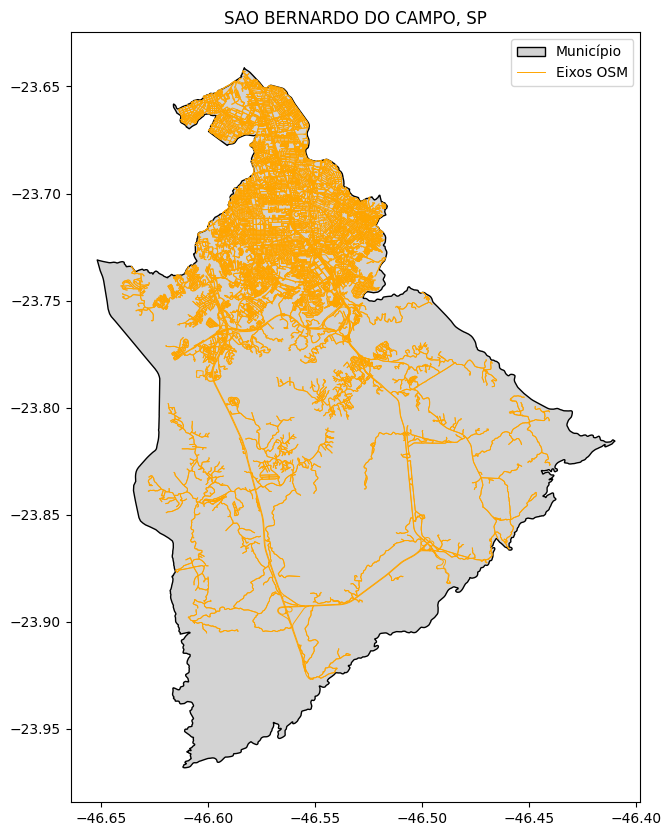

⬇️ Iniciando download no navegador…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 Concluído!


In [ ]:
#@title Download de dados espaciais segundo municipio
uf = "sp" # @param {"type":"string","placeholder":"1"}
nome_municipio = "são bernardo do campo"  #@param {type:"string"}
# selecione quais camadas baixar:
municipio = True # @param {"type":"boolean"}
setores = False # @param {"type":"boolean"}
enderecos = False # @param {"type":"boolean"}
faces = False # @param {"type":"boolean"}
eixos = True # @param {"type":"boolean"}

# monta a lista de layers
layers = []
if municipio:   layers.append(1)
if setores:  layers.append(2)
if enderecos:layers.append(3)
if faces:    layers.append(4)
if eixos:    layers.append(5)
# se nenhum marcado, baixa todas
if not layers:
    layers = [1,2,3,4,5]

print(f"Camadas selecionadas: {layers}")

# chama sua função
dados_municipio(
    sigla_uf=uf,
    nome_municipio=nome_municipio,
    layers=layers
)